In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, precision_recall_curve
from astroML.classification import GMMBayes
from astroML.utils import completeness_contamination

In [2]:
#loading and reading the data
data = pd.read_csv('../../solutions/galaxyquasar.csv')
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [3]:
y = [int(data['class'][i]=='QSO') for i in range(len(data))] #labels (1 = quasar, 0 = galaxy)

#data
u_g = np.array(data['u'] - data['g'])
g_r = np.array(data['g'] - data['r'])
r_i = np.array(data['r'] - data['i'])
i_z = np.array(data['i'] - data['z'])
X = np.vstack((u_g, g_r, r_i, i_z)).transpose()

First let's get an idea of the percentage of quasars in the data

In [4]:
print(np.sum(y)/len(y))

0.14268


We are interested in finding the quasars, so when selecting the threshold in our classification we will aim for a given value of completeness. But, given that the majority of observations in the data (~86%) correspond to galaxies, we'll have to make sure that the efficiency doesn't get to low

In [5]:
#splitting the data into trainign and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

We compare different classifiers, plotting ROC curves for each

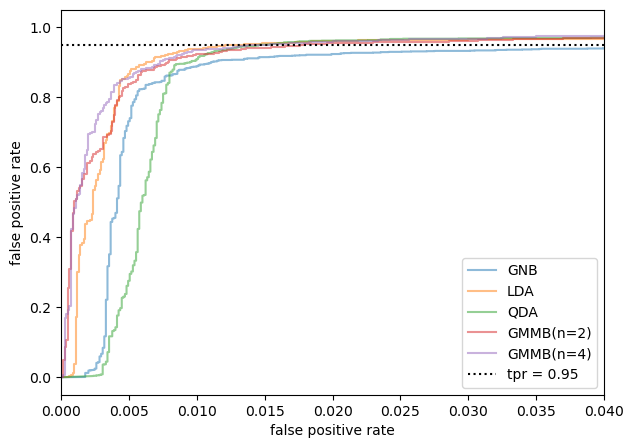

In [6]:

Classifiers = [GaussianNB(), LDA(), QDA(), GMMBayes(2), GMMBayes(4)]
Names  = ['GNB', 'LDA', 'QDA', 'GMMB(n=2)', 'GMMB(n=4)']

tpr_lim = 0.95 # desired completeness

col = [0, 1, 2, 3] # change to select different combinations of features (colors)

plt.figure(figsize=(7, 5))

for C_idx, C in enumerate(Classifiers):
    c = C
    c.fit(X_train[:, col], y_train) #training the model
    
    pred_proba = c.predict_proba(X_test[:, col]) # predicting on the test set (probability of each class)
    fpr, tpr, treshold = roc_curve(y_test, pred_proba[:, 1])

    plt.plot(fpr, tpr, label=Names[C_idx], alpha=0.5)
    plt.xlim(-0.0, 0.04)

#plotting
lab_tprlim = 'tpr = ' + f"{tpr_lim:.2f}"
plt.axhline(tpr_lim, ls='dotted', c='black', label=lab_tprlim)
plt.xlabel('false positive rate')
plt.ylabel('false positive rate')
plt.legend()
plt.show()

Aiming for a completeness of 95% we choose the classifier that minimizes the false positive rate, in this case Linear Discriminant Analysis. 

We now look for the probability threshold associated to the desired completeness, checking that corresponding efficiency doesn't get to high

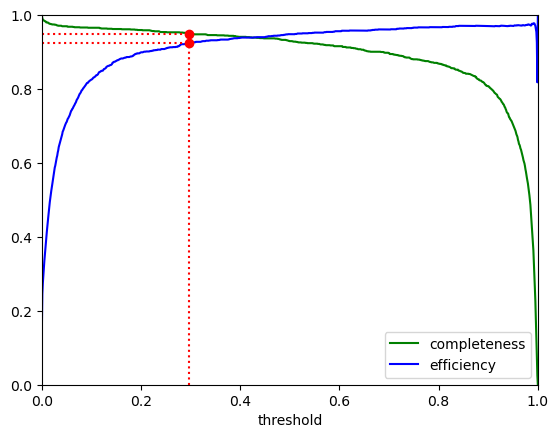

In [7]:
c = LDA()
c.fit(X_train[:, col], y_train)
pred_proba = c.predict_proba(X_test[:, col])

thresholds = np.linspace(0., 1., 1000)

completeness = []
efficiency = []
thresh = 0.
eff = 0.
s= 0. # switch  

for t in thresholds:
    y_pred = (pred_proba[:, 1] >= t)

    # completeness and contamination for given threshold
    compl_t, contam_t = completeness_contamination(y_pred, y_test)
    completeness.append(compl_t)
    efficiency.append(1-contam_t) # efficency = 1 - completeness

    # getting the threshold associated to the desired completeness
    if (compl_t <= tpr_lim and s==0.):
        thresh = t
        eff = 1-contam_t
        s=1

#plotting the results
plt.plot(thresholds, completeness, c='green', label='completeness')
plt.plot(thresholds, efficiency, c='blue', label='efficiency')
plt.plot([0., thresh], [tpr_lim, tpr_lim], ls='dotted', c='red')
plt.plot([0., thresh], [eff, eff], ls='dotted', c='red')
plt.plot([thresh, thresh], [0., tpr_lim], ls='dotted', c='red')
plt.plot([thresh], [eff], "ro")
plt.plot([thresh], [tpr_lim], "ro")
plt.xlim(0., 1.)
plt.ylim(0., 1.)
plt.xlabel('threshold')
plt.legend()

In [9]:
print(f"Threshold: {thresh:.2f}")
print(f"Completeness: {tpr_lim:.2f}")
print(f"Efficiency: {eff:.2f}")

Threshold: 0.30
Completeness: 0.95
Efficiency: 0.92


The efficiency remains >90%, we deem it satisfactory (keeping in mind that for different applications we might need a higher value, in that case it would be best to fix the desired efficiency value)

## Classification considering single colors

Up to this point we have used all the features of the X data matrix for our classification. Now let's explore what happens if we consider one 'color' at a time, the aim being to determine which features are best able to discern between the classes.

First let's plot the distribution of values for each color


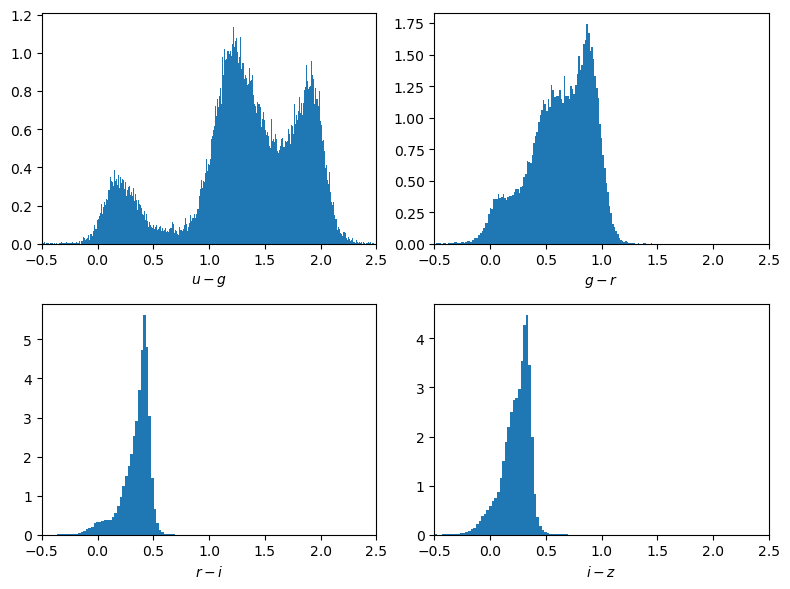

In [ ]:
colors = ['$u-g$', '$g-r$', '$r-i$', '$i-z$']

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.ravel()

for idx, color in enumerate(colors):
    ax = axes[idx]
    ax.hist(X[:, idx], 1000, density=True)
    ax.set_xlim(-0.5, 2.5)
    ax.set_xlabel(color)

plt.tight_layout()
plt.show()

At first glance it seems like the usefull information for classifing the classes is highest in the $u - g$ distribution, and then progressively decreases for each of the other colors. Let's see if a ROC curve (considering each feature separately) agrees with this intuition 

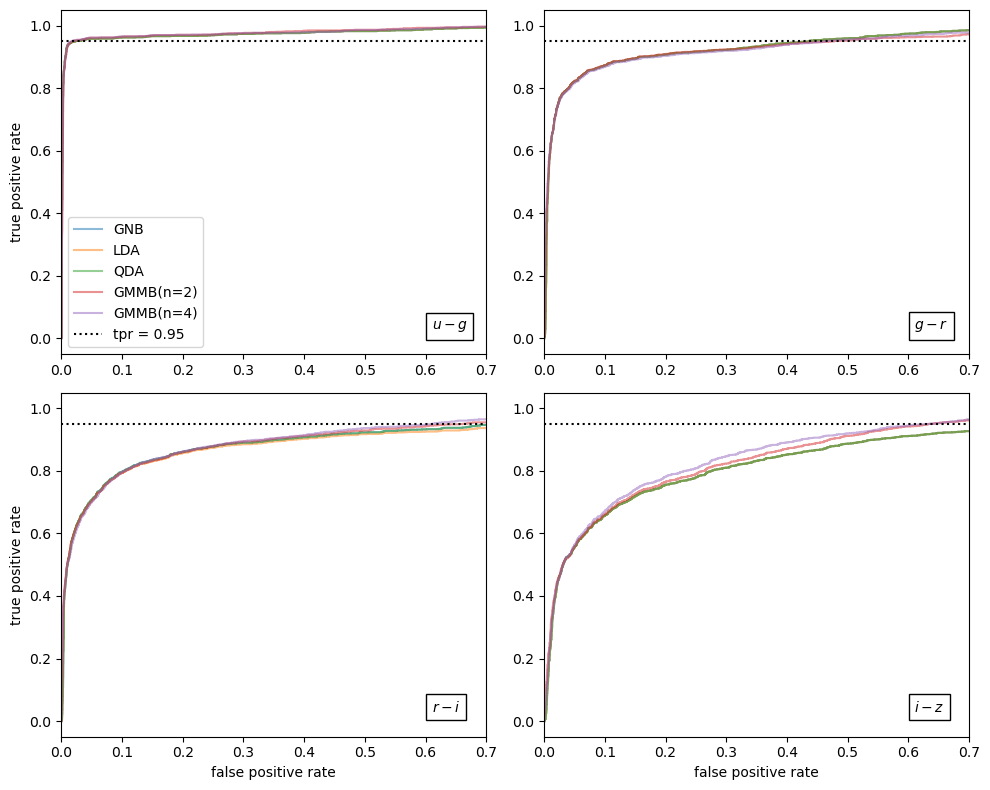

In [ ]:

fig, axes = plt.subplots(2,2, figsize=(10, 8))
axes = axes.ravel()

for idx, color in enumerate(colors):

    ax = axes[idx]

    for C_idx, C in enumerate(Classifiers):
        c = C
        c.fit(X_train[:, idx][:, None], y_train)
        pred_proba = c.predict_proba(X_test[:, idx][:, None])
        fpr, tpr, treshold = roc_curve(y_test, pred_proba[:, 1])

        ax.plot(fpr, tpr, label=Names[C_idx], alpha=0.5)

    if (idx==2 or idx==3):
        ax.set_xlabel('false positive rate')
    if (idx==0 or idx==2):
        ax.set_ylabel('true positive rate')   
    ax.text(0.61, 0.03, color, bbox=dict(ec='k', fc='w'))
    ax.axhline(tpr_lim, ls='dotted', c='black', label=lab_tprlim)
    ax.set_xlim(0.0, 0.7)
    if (idx==0):
        ax.legend() 

  
plt.tight_layout()
plt.show()    

As expected the classification quality decreases as the 'multimodality' of the feature distribution decreases